# XGBoost Binary Forex Classifier — MLflow Experiment

End-to-end training notebook for binary short/long forex prediction using the ForexPipeline.
Neutral triple-barrier labels are dropped so the model learns only decisive short vs long outcomes.


In [1]:
import os
import json
import tempfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
import mlflow
import mlflow.xgboost

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    log_loss, brier_score_loss, balanced_accuracy_score,
    matthews_corrcoef,
)
from sklearn.calibration import calibration_curve

from Pipeline.pipeline import ForexDataLoader, ForexPipeline

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Configuration

Edit `DATA_CFG` and `XGB_PARAMS` here — everything downstream reads from these dicts.

In [ ]:
DATA_CFG = {
    "pair":             "EURUSD",
    "years":            [2022, 2023],
    "timeframe":        "H1",
    "weekends":         "filled",  # "filled" | "nogap" | "gaps"
    # normalization: "log_returns" | "fracdiff" | "raw"
    "norm_method":      "fracdiff",
    # Binary notebook uses triple_barrier and drops neutral tb_label=0 rows.
    "target_type":      "triple_barrier",
    "target_col":       "tb_label",
    "lags":             [1, 2, 5, 10],
    "target_horizons":  [1, 5, 15],
    "gap_bars":         50,
    # scaling: "global" (ForexScaler) | "rolling" (RollingScaler), none for no scaling
    "scaling":          "none",
    "window_size":       500,  # only used if scaling="rolling", 200-500 is ok
    "fracdiff_d":       0.3,
    "threshold":        6*1e-4,
    "k_up":             2.0,
    "k_down":           2.0,
    "horizon_bars":     20,
}

XGB_PARAMS = {
    "n_estimators":         1000,
    "max_depth":            5,
    "learning_rate":        0.05,
    "subsample":            0.8,
    "colsample_bytree":     0.8,
    "min_child_weight":     150,
    "gamma":                0.1,
    "reg_alpha":            0.1,
    "reg_lambda":           1.0,
    "early_stopping_rounds":20,
    "objective":            "binary:logistic",
    "eval_metric":          "logloss",
    "random_state":         42,
    "n_jobs":               -1,
    "barrier_price":    "hl",
    "barrier_norm_method": "raw",
}

# MLflow tracking DB — stored inside the project folder
MLFLOW_DB        = f"sqlite:///{os.path.abspath('mlflow.db')}"
EXPERIMENT_NAME  = "xgboost_forex_binary"

print(f"DATA_CFG  : {json.dumps(DATA_CFG, indent=2)}")
print(f"XGB_PARAMS: {json.dumps(XGB_PARAMS, indent=2)}")
print(f"MLflow DB : {MLFLOW_DB}")


DATA_CFG  : {
  "pair": "EURUSD",
  "years": [
    2022,
    2023
  ],
  "timeframe": "H1",
  "weekends": "filled",
  "norm_method": "fracdiff",
  "target_type": "triple_barrier",
  "target_col": "tb_label",
  "lags": [
    1,
    2,
    5,
    10
  ],
  "target_horizons": [
    1,
    5,
    15
  ],
  "gap_bars": 50,
  "scaling": "none",
  "window_size": 500,
  "fracdiff_d": 0.3,
  "threshold": 0.0006000000000000001,
  "k_up": 2.0,
  "k_down": 2.0,
  "horizon_bars": 20
}
XGB_PARAMS: {
  "n_estimators": 1000,
  "max_depth": 5,
  "learning_rate": 0.05,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "min_child_weight": 150,
  "gamma": 0.1,
  "reg_alpha": 0.1,
  "reg_lambda": 1.0,
  "early_stopping_rounds": 20,
  "objective": "binary:logistic",
  "eval_metric": "logloss",
  "random_state": 42,
  "n_jobs": -1
}
MLflow DB : sqlite:////home/anton/Trade_bot/mlflow.db


## 1 — Load Raw M1 Data

In [23]:
loader = ForexDataLoader()
df_m1  = loader.load_and_merge(
    "histdata/",
    pair=DATA_CFG["pair"],
    years=DATA_CFG["years"],weekends=DATA_CFG["weekends"]
)

print(f"Raw M1 shape : {df_m1.shape}")
print(f"Date range   : {df_m1.index.min()}  →  {df_m1.index.max()}")
df_m1.head(3)

[Loader] EURUSD: 372,865 M1 bars  |  2022-01-02 17:03:00 → 2022-12-30 16:58:00
[Loader] EURUSD: 322,638 M1 bars  |  2023-01-01 17:04:00 → 2023-12-29 16:58:00
[Loader] Merged EURUSD: 1,045,436 M1 bars  |  2022-01-02 17:03:00 → 2023-12-29 16:58:00
Raw M1 shape : (1045436, 5)
Date range   : 2022-01-02 17:03:00  →  2023-12-29 16:58:00


,open,high,low,close,volume
2022-01-02 17:03:00,1.13690,1.13690,1.13690,1.13690,1.0
2022-01-02 17:04:00,1.13689,1.13689,1.13689,1.13689,1.0
2022-01-02 17:05:00,1.13692,1.13692,1.13692,1.13692,1.0


## 2 — Run Pipeline

In [24]:
pipeline = ForexPipeline(
    lags            = DATA_CFG["lags"],
    target_horizons = DATA_CFG["target_horizons"],
    gap_bars        = DATA_CFG["gap_bars"],
    scaling         = DATA_CFG["scaling"],
    norm_method     = DATA_CFG["norm_method"],
    fracdiff_d      = DATA_CFG["fracdiff_d"],
    target_type     = DATA_CFG["target_type"],
    k_up            = DATA_CFG["k_up"],
    k_down          = DATA_CFG["k_down"],
    horizon_bars    = DATA_CFG["horizon_bars"],
    barrier_price   = DATA_CFG.get("barrier_price", "hl"),
    barrier_norm_method = DATA_CFG.get("barrier_norm_method", "raw"),
    threshold       = DATA_CFG["threshold"],
)

results     = pipeline.run(df_m1, timeframe=DATA_CFG["timeframe"])
feature_cols = results["feature_cols"]
target_col  = DATA_CFG["target_col"]

for split in ["train", "val", "test"]:
    df_s = results[split]
    print(f"{split:5s}: {len(df_s):6d} rows  "
          f"{df_s.index.min().date()} → {df_s.index.max().date()}")

print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")


  Pipeline: EURUSD | H1 | norm=fracdiff | target=triple_barrier | weekends=nogap
[Resample] M1 → H1: 17,424 bars
[Features] Computing...
[Features] 32 features | 17,208 clean bars

[Splitter] Walk-forward split (gap=50 bars):
  Train :  10,324 bars  2022-01-10 → 2023-03-17
  Val   :   3,441 bars  2023-03-19 → 2023-08-09
  Test  :   3,343 bars  2023-08-11 → 2023-12-28
train:  10324 rows  2022-01-10 → 2023-03-17
val  :   3441 rows  2023-03-19 → 2023-08-09
test :   3343 rows  2023-08-11 → 2023-12-28

Features (32): ['rsi_14', 'rsi_14_speed', 'rsi_14_accel', 'rsi_14_cross_50', 'rsi_14_cross_70', 'rsi_21', 'rsi_21_speed', 'rsi_21_accel', 'rsi_21_cross_50', 'rsi_21_cross_70', 'adx_14', 'di_diff', 'adx_delta', 'dist_ema200', 'atr_rel', 'bb_pct_b', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_monday', 'is_friday', 'body_ratio', 'shadow_ratio', 'body_gap', 'ret_skew', 'ret_kurt', 'vol_ewma', 'close_lag1', 'close_lag2', 'close_lag5', 'close_lag10']


## 3 — Extract Binary Short / Long X / y Arrays


In [25]:
# Binary class mapping after filtering triple_barrier labels:
#   0 = short hit (tb_label = -1 : price hit the lower barrier)
#   1 = long hit  (tb_label = +1 : price hit the upper barrier)
# Neutral rows (tb_label = 0) are dropped from each split.
CLASS_LABELS = {0: "short", 1: "long"}


def extract_xy(results, split, target_col, feature_cols):
    X, y_raw = pipeline.get_xy(results[split], target_col, feature_cols)

    if target_col != "tb_label":
        raise ValueError("Binary short/long notebook expects DATA_CFG['target_col'] == 'tb_label'.")

    decisive_mask = y_raw != 0
    X = X[decisive_mask]
    y = (y_raw[decisive_mask] == 1).astype(int)  # -1 -> 0 short, +1 -> 1 long

    if len(y) == 0:
        raise ValueError(f"{split} split has no short/long samples after dropping neutral labels.")

    return X, y


X_train, y_train = extract_xy(results, "train", target_col, feature_cols)
X_val,   y_val   = extract_xy(results, "val",   target_col, feature_cols)
X_test,  y_test  = extract_xy(results, "test",  target_col, feature_cols)

print("Binary class mapping:")
for cls, lbl in CLASS_LABELS.items():
    print(f"  {cls} = {lbl}")
print()

lag_features = [c for c in feature_cols if "lag" in c]
print(f"Previous-tick context features: {lag_features}")
print()

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    total = len(y)
    unique, counts = np.unique(y, return_counts=True)
    dist_str = "  ".join(
        f"{CLASS_LABELS[int(k)]}({int(k)}): {int(v):,} ({int(v)/total:.1%})"
        for k, v in zip(unique, counts)
    )
    print(f"{name:5s}: {total:,} decisive samples  |  {dist_str}")


Binary class mapping:
  0 = short
  1 = long

Previous-tick context features: ['close_lag1', 'close_lag2', 'close_lag5', 'close_lag10']

train: 7,468 decisive samples  |  short(0): 3,917 (52.5%)  long(1): 3,551 (47.5%)
val  : 2,482 decisive samples  |  short(0): 1,255 (50.6%)  long(1): 1,227 (49.4%)
test : 2,428 decisive samples  |  short(0): 1,102 (45.4%)  long(1): 1,326 (54.6%)


## 4 — Train XGBoost + Log Everything to MLflow

In [26]:
mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.set_experiment(EXPERIMENT_NAME)

run_name = f"{DATA_CFG['pair']}_{DATA_CFG['timeframe']}_{DATA_CFG['norm_method']}_binary_short_long"

with mlflow.start_run(run_name=run_name) as run:
    RUN_ID = run.info.run_id

    # ── Parameters ──────────────────────────────────────────────────────────
    mlflow.log_params({f"data_{k}": str(v) for k, v in DATA_CFG.items()})
    mlflow.log_params({f"xgb_{k}": v for k, v in XGB_PARAMS.items()})
    mlflow.log_param("label_mode", "drop_neutral_short0_long1")

    # Data date ranges
    mlflow.log_params({
        "raw_m1_start":  str(df_m1.index.min()),
        "raw_m1_end":    str(df_m1.index.max()),
        "train_start":   str(results["train"].index.min()),
        "train_end":     str(results["train"].index.max()),
        "val_start":     str(results["val"].index.min()),
        "val_end":       str(results["val"].index.max()),
        "test_start":    str(results["test"].index.min()),
        "test_end":      str(results["test"].index.max()),
        "n_features":    len(feature_cols),
        "train_samples": len(X_train),
        "val_samples":   len(X_val),
        "test_samples":  len(X_test),
        "train_long_rate":float(y_train.mean()),
        "val_long_rate":  float(y_val.mean()),
        "test_long_rate": float(y_test.mean()),
    })

    # Feature list as artifact
    mlflow.log_dict({"features": feature_cols}, "features.json")

    # ── Train ────────────────────────────────────────────────────────────────
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

    mlflow.log_param("best_iteration", model.best_iteration)

    # ── Log model ────────────────────────────────────────────────────────────
    mlflow.xgboost.log_model(model, "model")

    # ── Metrics per split ────────────────────────────────────────────────────
    # proba shape: (n, 2) → [P(short/0), P(long/1)]
    split_metrics = {}
    for sname, X, y in [("train", X_train, y_train),
                         ("val",   X_val,   y_val),
                         ("test",  X_test,  y_test)]:
        proba      = model.predict_proba(X)
        proba_long = proba[:, 1]
        pred       = model.predict(X)
        m = {
            "auc":           roc_auc_score(y, proba_long),
            "avg_precision": average_precision_score(y, proba_long),
            "logloss":       log_loss(y, proba),
            "brier":         brier_score_loss(y, proba_long),
            "f1":            f1_score(y, pred, zero_division=0),
            "precision":     precision_score(y, pred, zero_division=0),
            "recall":        recall_score(y, pred, zero_division=0),
            "balanced_acc":  balanced_accuracy_score(y, pred),
            "mcc":           matthews_corrcoef(y, pred),
        }
        split_metrics[sname] = m
        mlflow.log_metrics({f"{sname}_{k}": v for k, v in m.items()})

    print(f"Run ID  : {RUN_ID}")
    print(f"Best iter: {model.best_iteration}")
    print(pd.DataFrame(split_metrics).T.round(4))


2026/05/10 09:55:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/10 09:55:07 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/anton/Trade_bot
2026/05/10 09:55:07 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/anton/Trade_bot
2026/05/10 09:55:07 INFO mlflow.utils.environment: Detected uv project at /home/anton/Trade_bot. Attempting to export requirements via 'uv export'.
2026/05/10 09:55:07 INFO mlflow.utils.uv_utils: Exported 224 dependencies via uv
2026/05/10 09:55:07 INFO mlflow.utils.environment: Successfully exported 224 requirements from uv project. Skipping package capture based inference.
2026/05/10 09:55:08 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - einops (current: 0.8.1, required: einops==0.8.2)
To fix the mismatches, call `mlflow.pyfunc.get_

Run ID  : 91b3157a6c7e4a67abac0f2de8bf26c7
Best iter: 17
          auc  avg_precision  logloss   brier      f1  precision  recall  \
train  0.6681         0.6459   0.6703  0.2386  0.4974     0.6525  0.4019   
val    0.5495         0.5349   0.6917  0.2493  0.2977     0.5922  0.1989   
test   0.5231         0.5603   0.7016  0.2542  0.4177     0.6101  0.3175   

       balanced_acc     mcc  
train        0.6039  0.2281  
val          0.5325  0.0873  
test         0.5367  0.0810  


## 5 — Analysis: ROC Curves (train / val / test)

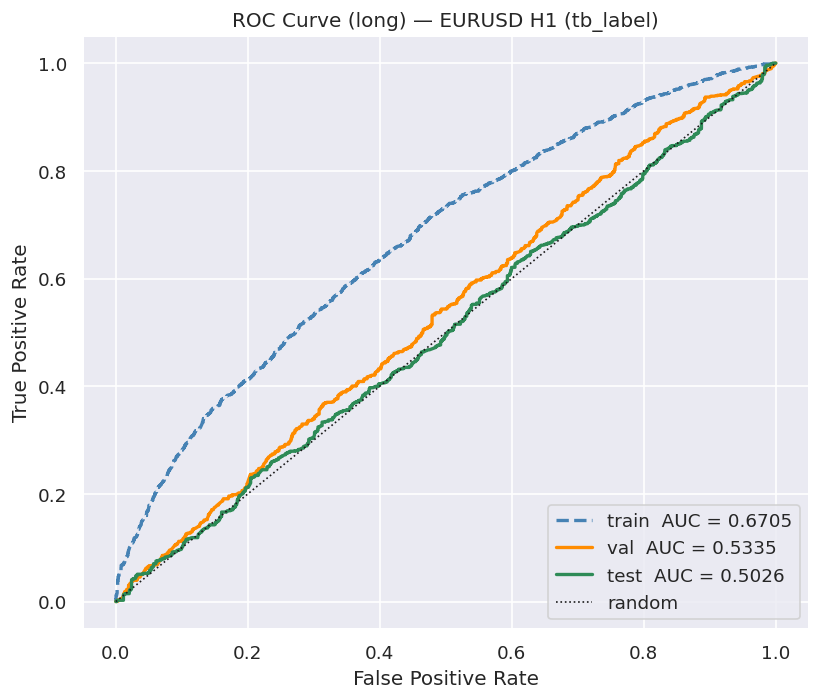

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = {"train": "steelblue", "val": "darkorange", "test": "seagreen"}
styles = {"train": "--",        "val": "-",          "test": "-"}

# Plot ROC for long class in the binary short/long classifier.
for sname, X, y in [("train", X_train, y_train),
                     ("val",   X_val,   y_val),
                     ("test",  X_test,  y_test)]:
    proba_long = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba_long)
    auc = roc_auc_score(y, proba_long)
    ax.plot(fpr, tpr, ls=styles[sname], color=colors[sname],
            label=f"{sname}  AUC = {auc:.4f}", lw=2)

ax.plot([0, 1], [0, 1], 'k:', lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (long) — {DATA_CFG['pair']} {DATA_CFG['timeframe']} ({DATA_CFG['target_col']})")
ax.legend(loc="lower right")
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "roc_curve.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")

plt.show()


## 6 — Analysis: Precision-Recall Curves

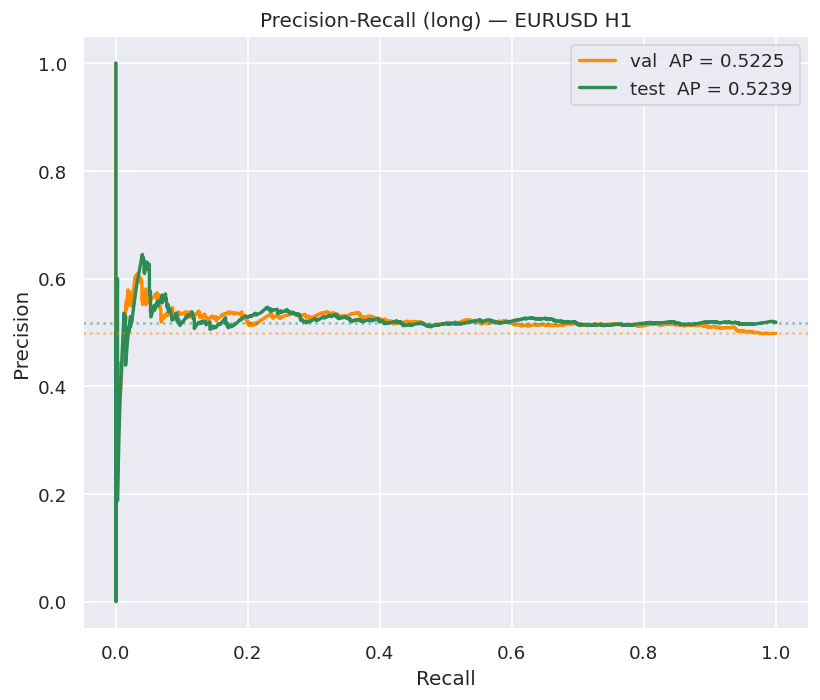

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

# Plot PR for long class in the binary short/long classifier.
for sname, X, y in [("val",  X_val,  y_val),
                     ("test", X_test, y_test)]:
    proba_long = model.predict_proba(X)[:, 1]
    prec, rec, _ = precision_recall_curve(y, proba_long)
    ap = average_precision_score(y, proba_long)
    ax.plot(rec, prec, color=colors[sname],
            label=f"{sname}  AP = {ap:.4f}", lw=2)

# No-skill baseline (long base rate among decisive short/long samples)
for sname, y in [("val", y_val), ("test", y_test)]:
    ax.axhline(y.mean(), ls=':', color=colors[sname], alpha=0.5)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall (long) — {DATA_CFG['pair']} {DATA_CFG['timeframe']}")
ax.legend()
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "pr_curve.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")

plt.show()


## 7 — Analysis: Confusion Matrices (val + test)

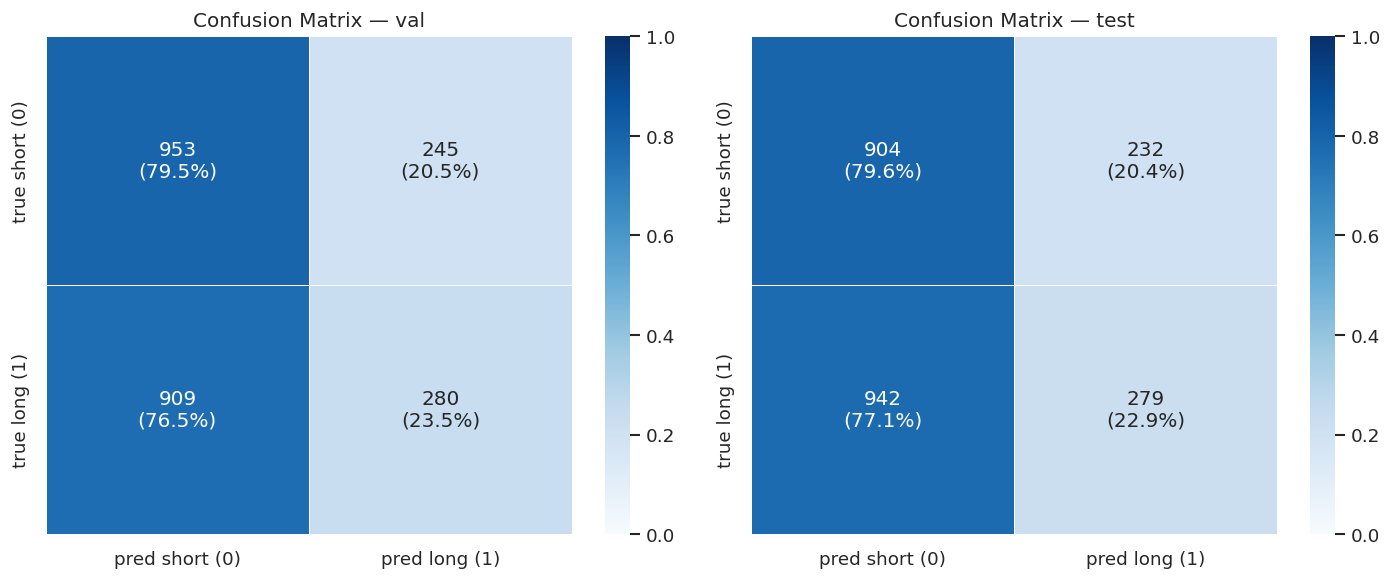

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_labels = [f"{CLASS_LABELS[i]} ({i})" for i in range(2)]

for ax, (sname, X, y) in zip(axes, [("val", X_val, y_val), ("test", X_test, y_test)]):
    pred    = model.predict(X)
    cm      = confusion_matrix(y, pred, labels=[0, 1])
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
    annot   = np.array([[f"{cm[i,j]}\n({cm_norm[i,j]:.1%})" for j in range(2)] for i in range(2)])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=[f"pred {l}" for l in cm_labels],
                yticklabels=[f"true {l}" for l in cm_labels],
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f"Confusion Matrix — {sname}")

plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "confusion_matrices.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")

plt.show()


## 8 — Analysis: Classification Report

In [10]:
report_frames = []
_target_names = [CLASS_LABELS[i] for i in range(2)]   # ["short", "long"]

for sname, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
    pred = model.predict(X)

    # Class distribution
    total = len(y)
    unique, counts = np.unique(y, return_counts=True)
    dist = {CLASS_LABELS[int(k)]: int(v) for k, v in zip(unique, counts)}
    print(f"\n── {sname}  (n={total:,}) ──")
    print("  Class counts: " + "  ".join(f"{lbl}: {cnt:,} ({cnt/total:.1%})"
                                          for lbl, cnt in dist.items()))

    print(classification_report(y, pred, labels=[0, 1], target_names=_target_names, zero_division=0))

    rpt    = classification_report(y, pred, labels=[0, 1], target_names=_target_names, output_dict=True, zero_division=0)
    df_rpt = pd.DataFrame(rpt).T.round(4)
    df_rpt.insert(0, "split", sname)
    report_frames.append(df_rpt)

combined_report = pd.concat(report_frames)

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "classification_report.csv")
        combined_report.to_csv(path)
        mlflow.log_artifact(path, "reports")



── val  (n=2,387) ──
  Class counts: short: 1,198 (50.2%)  long: 1,189 (49.8%)
              precision    recall  f1-score   support

       short       0.51      0.80      0.62      1198
        long       0.53      0.24      0.33      1189

    accuracy                           0.52      2387
   macro avg       0.52      0.52      0.47      2387
weighted avg       0.52      0.52      0.48      2387


── test  (n=2,357) ──
  Class counts: short: 1,136 (48.2%)  long: 1,221 (51.8%)
              precision    recall  f1-score   support

       short       0.49      0.80      0.61      1136
        long       0.55      0.23      0.32      1221

    accuracy                           0.50      2357
   macro avg       0.52      0.51      0.46      2357
weighted avg       0.52      0.50      0.46      2357



## 9b — Binary Class Prediction Quality


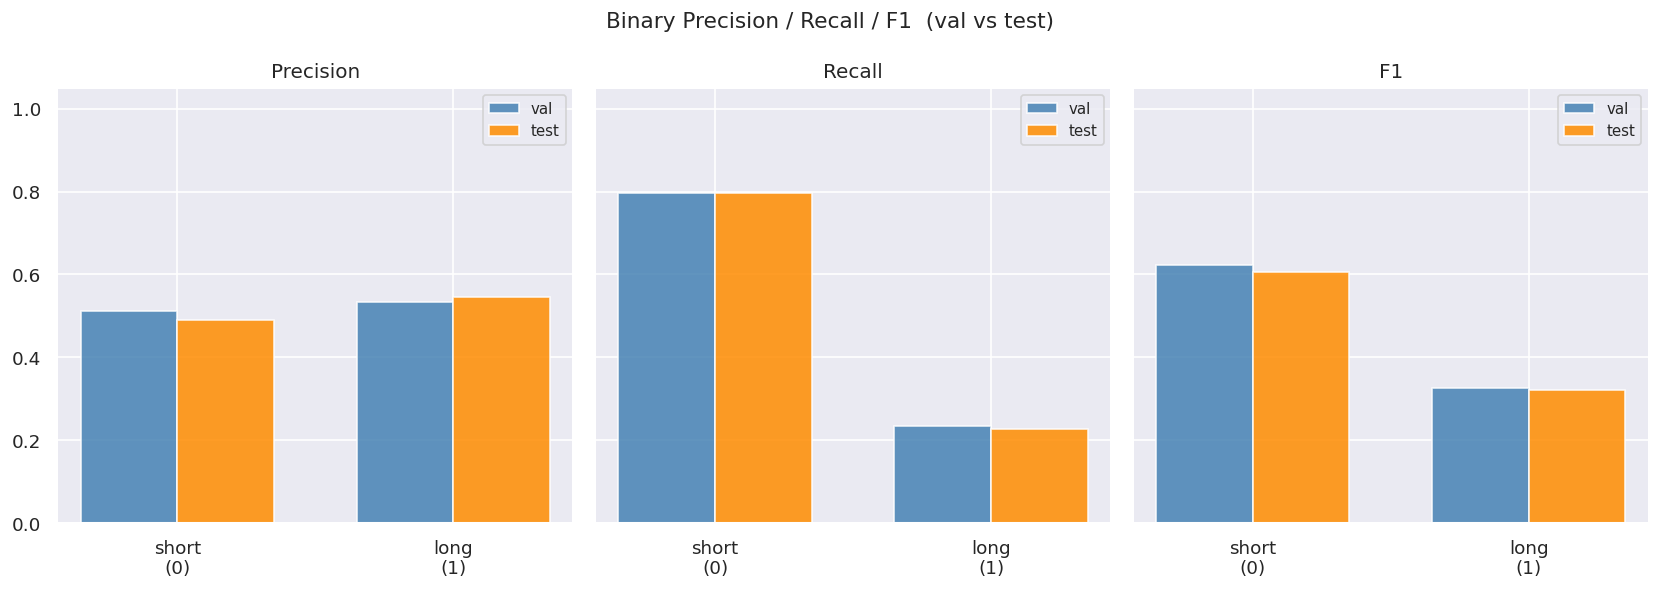

In [11]:
_classes = list(CLASS_LABELS.keys())   # [0, 1]
_splits  = [("val", X_val, y_val), ("test", X_test, y_test)]
_clr     = {"val": "steelblue", "test": "darkorange"}

_x      = np.arange(len(_classes))
_w      = 0.35
_labels = [f"{CLASS_LABELS[c]}\n({c})" for c in _classes]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, metric_fn, title in zip(
    axes,
    [precision_score, recall_score, f1_score],
    ["Precision", "Recall", "F1"],
):
    for offset, (sname, X, y) in zip([-_w / 2, _w / 2], _splits):
        scores = metric_fn(y, model.predict(X), labels=_classes, average=None, zero_division=0)
        ax.bar(_x + offset, scores, _w, label=sname, color=_clr[sname], alpha=0.85)
    ax.set_xticks(_x)
    ax.set_xticklabels(_labels)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle("Binary Precision / Recall / F1  (val vs test)", fontsize=13)
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        _p = os.path.join(tmp, "binary_prf1.png")
        fig.savefig(_p)
        mlflow.log_artifact(_p, "plots")
plt.show()


## 9 — Analysis: Learning Curves (Overfitting Diagnostic)

Val-Train logloss gap at best iter: 0.009033


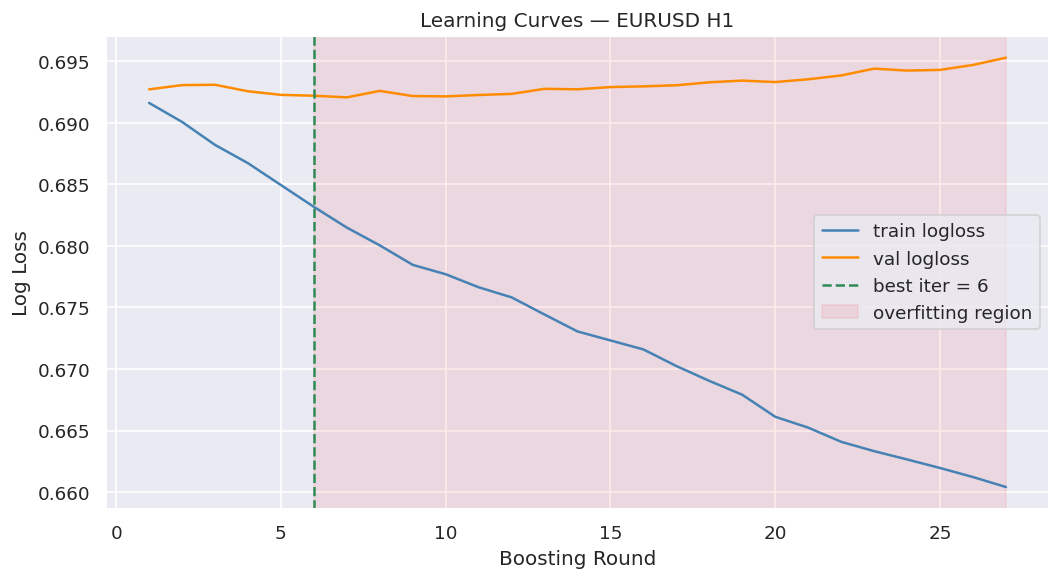

In [12]:
evals = model.evals_result()
# keys: 'validation_0' = train, 'validation_1' = val
train_logloss = evals["validation_0"]["logloss"]
val_logloss   = evals["validation_1"]["logloss"]
rounds = range(1, len(train_logloss) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rounds, train_logloss, label="train logloss", color="steelblue", lw=1.5)
ax.plot(rounds, val_logloss,   label="val logloss",   color="darkorange", lw=1.5)
ax.axvline(model.best_iteration, ls='--', color='seagreen', lw=1.5,
           label=f"best iter = {model.best_iteration}")

# Shade overfitting region
if model.best_iteration < len(train_logloss):
    ax.axvspan(model.best_iteration, len(train_logloss), alpha=0.08, color='red',
               label="overfitting region")

ax.set_xlabel("Boosting Round")
ax.set_ylabel("Log Loss")
ax.set_title(f"Learning Curves — {DATA_CFG['pair']} {DATA_CFG['timeframe']}")
ax.legend()
plt.tight_layout()

# Log overfit gap as metric
overfit_gap = val_logloss[model.best_iteration - 1] - train_logloss[model.best_iteration - 1]
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metric("overfit_logloss_gap", overfit_gap)
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "learning_curves.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")

print(f"Val-Train logloss gap at best iter: {overfit_gap:.6f}")
plt.show()

## 10 — Analysis: Feature Importance (Gain / Weight / Cover)

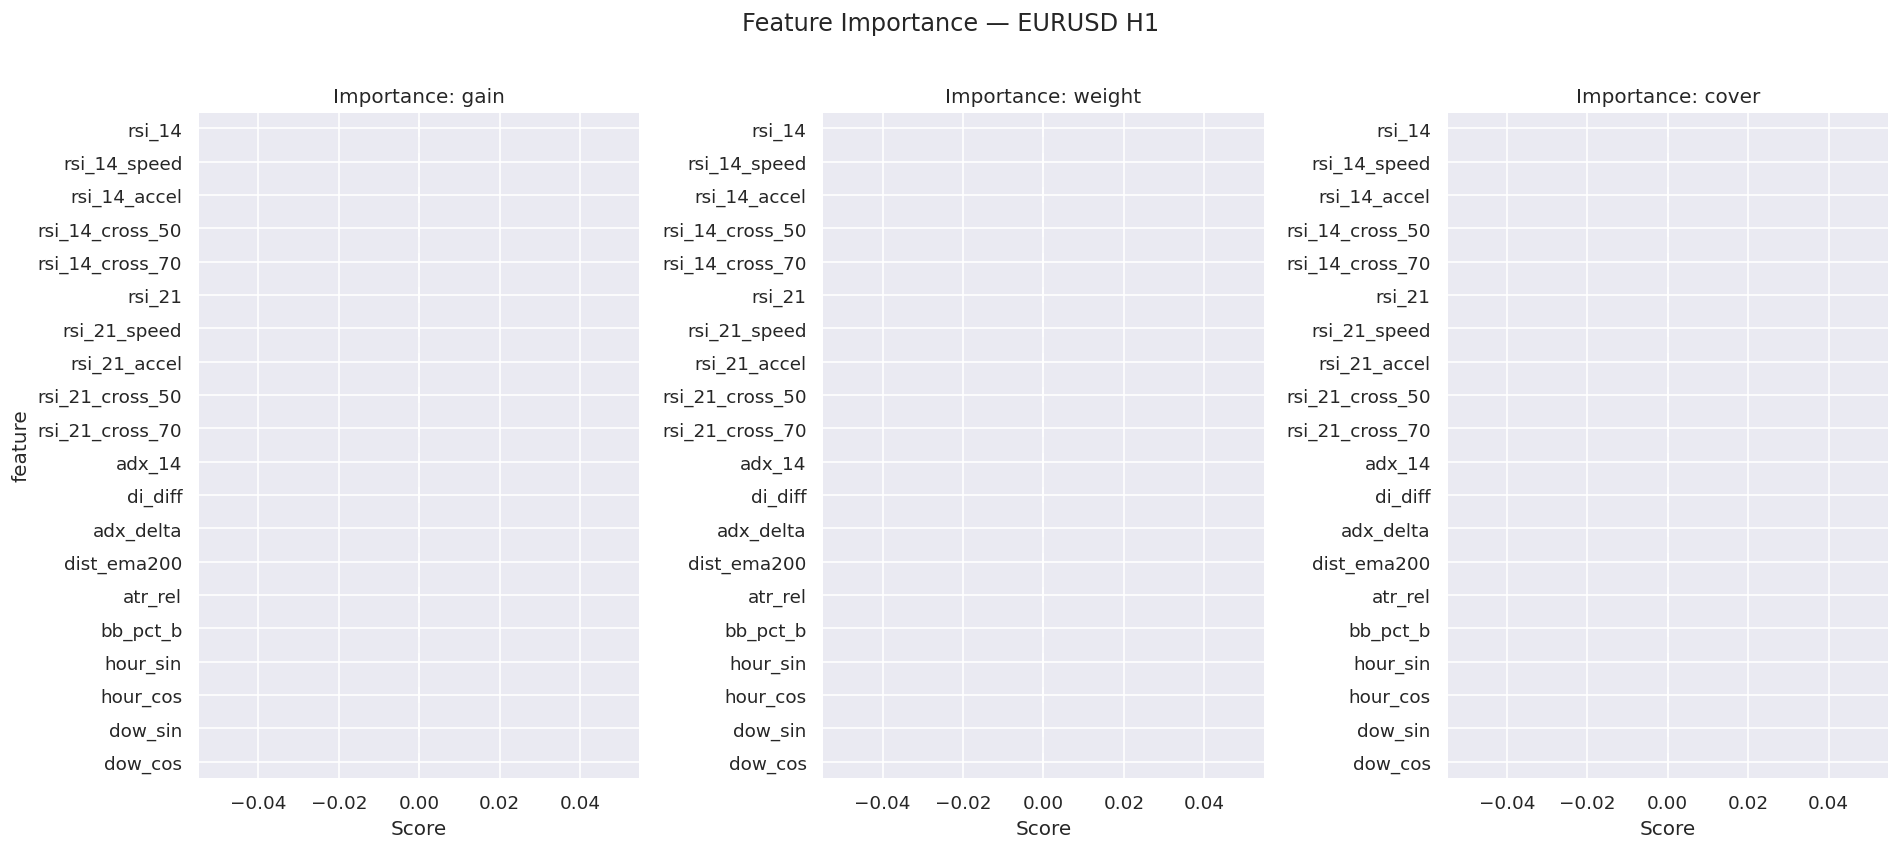

,gain,weight,cover
feature,,,
rsi_14,0.0,0.0,0.0
rsi_14_speed,0.0,0.0,0.0
rsi_14_accel,0.0,0.0,0.0
rsi_14_cross_50,0.0,0.0,0.0
rsi_14_cross_70,0.0,0.0,0.0
rsi_21,0.0,0.0,0.0
rsi_21_speed,0.0,0.0,0.0
rsi_21_accel,0.0,0.0,0.0
rsi_21_cross_50,0.0,0.0,0.0


In [13]:
importance_types = ["gain", "weight", "cover"]
imp_frames = {}

for imp_type in importance_types:
    scores = model.get_booster().get_score(importance_type=imp_type)
    df_imp = pd.Series(scores, name=imp_type).reindex(feature_cols).fillna(0)
    df_imp = df_imp.sort_values(ascending=False)
    imp_frames[imp_type] = df_imp

imp_combined = pd.DataFrame(imp_frames)
imp_combined.index.name = "feature"

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
for ax, imp_type in zip(axes, importance_types):
    top20 = imp_frames[imp_type].head(20)
    top20.plot.barh(ax=ax, color="steelblue")
    ax.invert_yaxis()
    ax.set_title(f"Importance: {imp_type}")
    ax.set_xlabel("Score")

plt.suptitle(f"Feature Importance — {DATA_CFG['pair']} {DATA_CFG['timeframe']}", y=1.01)
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        img_path = os.path.join(tmp, "feature_importance.png")
        csv_path = os.path.join(tmp, "feature_importance.csv")
        fig.savefig(img_path)
        imp_combined.to_csv(csv_path)
        mlflow.log_artifact(img_path, "plots")
        mlflow.log_artifact(csv_path, "reports")

plt.show()
imp_combined.head(10)

## 11 — Analysis: Calibration Curve (Reliability Diagram)

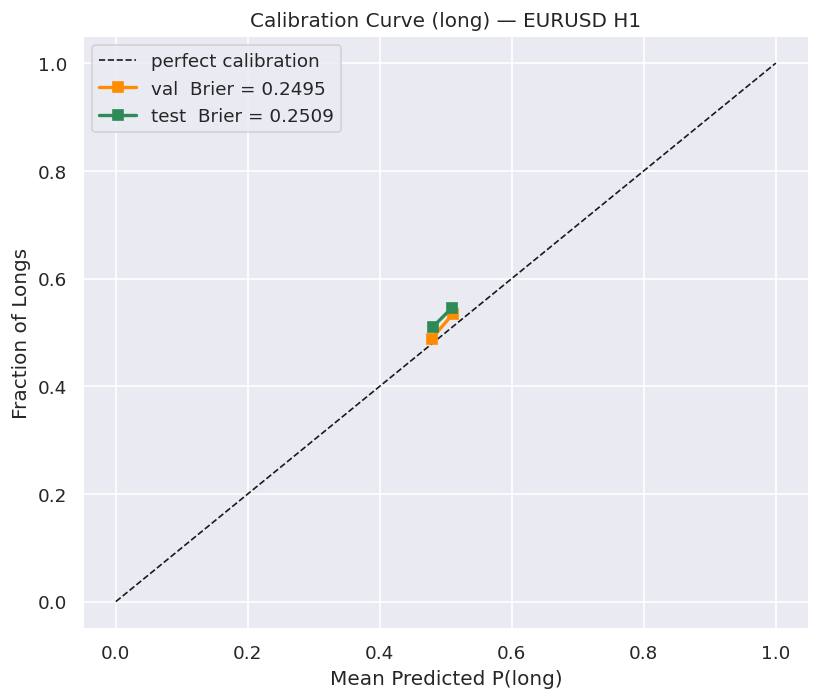

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label="perfect calibration")

brier_scores = {}
for sname, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
    proba_long = model.predict_proba(X)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, proba_long, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y, proba_long)
    brier_scores[sname] = brier
    ax.plot(mean_pred, frac_pos, 's-', color=colors[sname], lw=2,
            label=f"{sname}  Brier = {brier:.4f}")

ax.set_xlabel("Mean Predicted P(long)")
ax.set_ylabel("Fraction of Longs")
ax.set_title(f"Calibration Curve (long) — {DATA_CFG['pair']} {DATA_CFG['timeframe']}")
ax.legend()
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({f"{k}_brier": v for k, v in brier_scores.items()})
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "calibration_curve.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")

plt.show()


## 12 — Analysis: Metrics Comparison (Train / Val / Test)

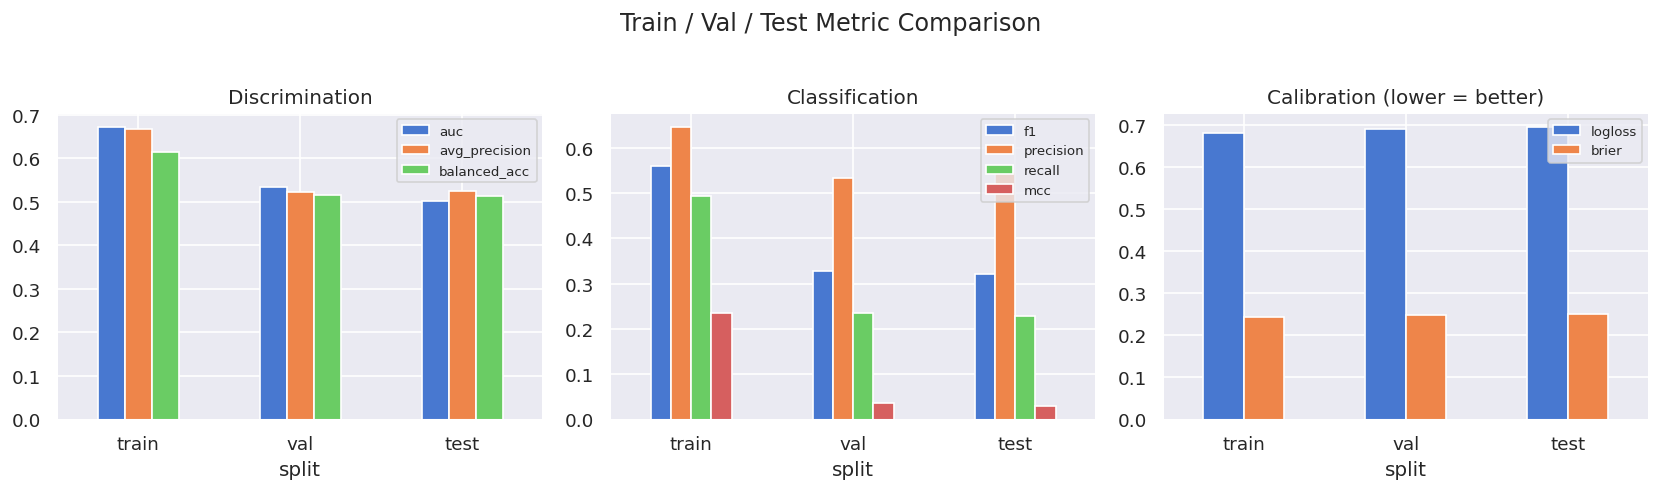

          auc  avg_precision  logloss   brier      f1  precision  recall  balanced_acc     mcc
split                                                                                         
train  0.6705         0.6665   0.6815  0.2442  0.5589     0.6448  0.4932        0.6144  0.2361
val    0.5335         0.5225   0.6921  0.2495  0.3267     0.5333  0.2355        0.5155  0.0374
test   0.5026         0.5239   0.6949  0.2509  0.3222     0.5460  0.2285        0.5121  0.0294


In [15]:
metrics_df = pd.DataFrame(split_metrics).T
metrics_df.index.name = "split"

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_metrics = [
    (["auc", "avg_precision", "balanced_acc"], "Discrimination"),
    (["f1", "precision", "recall", "mcc"],   "Classification"),
    (["logloss", "brier"],                    "Calibration (lower = better)"),
]

for ax, (cols, title) in zip(axes, plot_metrics):
    metrics_df[cols].plot.bar(ax=ax, rot=0)
    ax.set_title(title)
    ax.set_ylim(0)
    ax.legend(fontsize=8)

plt.suptitle("Train / Val / Test Metric Comparison", y=1.02)
plt.tight_layout()

with mlflow.start_run(run_id=RUN_ID):
    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "metrics_comparison.png")
        fig.savefig(path)
        mlflow.log_artifact(path, "plots")

plt.show()
print(metrics_df.round(4).to_string())


## 13 — Run Summary

In [16]:
required_summary_vars = ["RUN_ID", "split_metrics", "EXPERIMENT_NAME", "MLFLOW_DB", "DATA_CFG", "pd"]
missing_summary_vars = [name for name in required_summary_vars if name not in globals()]

if missing_summary_vars:
    print("Run summary is not available yet.")
    print("Missing variables: " + ", ".join(missing_summary_vars))
    print("Run the training/MLflow cell first, then rerun the analysis cells.")
else:
    print("=" * 60)
    print(f"  MLflow Run ID  : {RUN_ID}")
    print(f"  Experiment     : {EXPERIMENT_NAME}")
    print(f"  Tracking DB    : {MLFLOW_DB}")
    print(f"  Primary run    : {DATA_CFG['norm_method']} (d={DATA_CFG.get('fracdiff_d')})")
    print("  Label mode     : binary short/long, neutral dropped")
    print("=" * 60)
    print("  To browse the UI:")
    print(f"  mlflow ui --backend-store-uri {MLFLOW_DB}")
    print("  then open  http://127.0.0.1:5000")
    print("=" * 60)
    print()
    print("Logged artifacts:")
    for artifact in [
        "plots/roc_curve.png",
        "plots/pr_curve.png",
        "plots/confusion_matrices.png",
        "plots/binary_prf1.png",
        "plots/learning_curves.png",
        "plots/feature_importance.png",
        "plots/calibration_curve.png",
        "plots/metrics_comparison.png",
        "reports/classification_report.csv",
        "reports/feature_importance.csv",
        "features.json",
        "model/  (XGBoost model)",
    ]:
        print(f"  {artifact}")

    print()
    test_metrics = split_metrics.get("test", {})
    if test_metrics:
        print("Test metrics:")
        print(pd.Series(test_metrics).round(4).to_string())
    else:
        print("No test metrics were found in split_metrics.")


  MLflow Run ID  : 9350791b9dd841cf96e16e859fe8272c
  Experiment     : xgboost_forex_binary
  Tracking DB    : sqlite:////home/anton/Trade_bot/mlflow.db
  Primary run    : fracdiff (d=0.3)
  Label mode     : binary short/long, neutral dropped
  To browse the UI:
  mlflow ui --backend-store-uri sqlite:////home/anton/Trade_bot/mlflow.db
  then open  http://127.0.0.1:5000

Logged artifacts:
  plots/roc_curve.png
  plots/pr_curve.png
  plots/confusion_matrices.png
  plots/binary_prf1.png
  plots/learning_curves.png
  plots/feature_importance.png
  plots/calibration_curve.png
  plots/metrics_comparison.png
  reports/classification_report.csv
  reports/feature_importance.csv
  features.json
  model/  (XGBoost model)

Test metrics:
auc              0.5026
avg_precision    0.5239
logloss          0.6949
brier            0.2509
f1               0.3222
precision        0.5460
recall           0.2285
balanced_acc     0.5121
mcc              0.0294
